# Deep Learning
MATH70116<br>
Autumn 2026<br>
Lecturer: Tom Hadfield

## Example: Regression

In this example, we test neural networks in a task that involves *non-linear regression* with artificial data. We generate data $y^1,\ldots,y^N \in \mathbb{R}$ and $x^1,\ldots,x^N \in \mathbb{R}$ with $N = 1\,000\,000$ as follows. We first sample $x^1,\ldots,x^N$ independently from a $\mathrm{Uniform}(0,1)$ distribution. Then we set
	\begin{equation*}
	y^i = g\big(x^i\big) + \varepsilon^i, \quad i = 1,\ldots,N,
	\end{equation*}
	where $g(x) = \cos(10x)$, $x \in \mathbb{R}$, and $\varepsilon^1,\ldots,\varepsilon^N$ are independent $N(0,0.1)$-distributed variates.
	
Our aim is now to learn the function $g$ from the data by *supervised learning*, that is, by only using the data $x^1,\ldots,x^N$ with associated labels $y^1,\ldots,y^N$.

To this end, we train a neural network $\widehat{g}$
	using squared loss as loss function $\ell$, Adam optimisation algorithm with minibatches of size 100, over 5 epochs. We then compare the trained $\widehat{g}$ to $g$.
    
    
First, let us import the necessary libraries, and set plotting style.

In [1]:
import numpy as np
import numpy.random as npr
import torch
import matplotlib.pyplot as plt
plt.style.use('ggplot')

We first define the function $g(x) := \cos(10x)$, $x \in \mathbb{R}$. This is the function we try to learn from noisy data.

In [2]:
a = 10
def g(x):
    return np.cos(a*x)

We then generate the data $x^0,x^1,\ldots,x^{N-1}$ (we switch to the Python convention of starting indexation from $0$) from $\mathrm{Uniform}(0,1)$ and
\begin{equation*}
y^i = g(x^i) + \varepsilon^i, \quad i=0,1\ldots,N-1,
\end{equation*}
with iid $\varepsilon^i \sim N(0,0.1)$, $i = 0,1,\ldots,N-1$, for $N = 1\,000\,000$.

In [3]:
npr.seed(12345)
N = 10000 #1000000
var = 0.1
x = npr.uniform(0,1, (N,1))
eps = npr.normal(0, np.sqrt(var), (N,1))
y = g(x) + eps

Plot the first $1000$ samples:

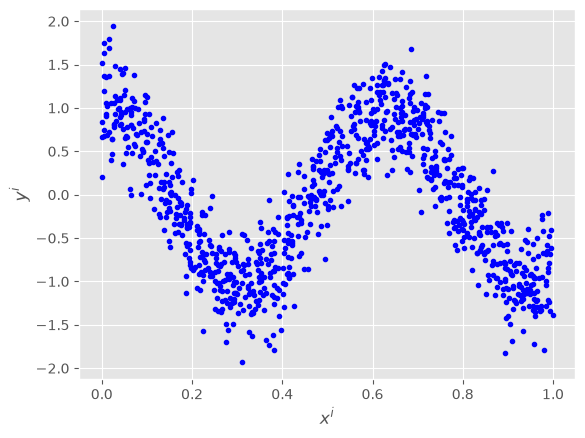

In [4]:
N_sub = 1000
plt.plot(x[0:N_sub,], y[0:N_sub,], "bo", markersize=3)
plt.xlabel(r"$x^i$")
plt.ylabel(r"$y^i$")
plt.show()

Now we define the neural network
\begin{equation*}
\widehat{g} \in \mathcal{N}_4(1,100,100,100,1; \mathrm{ReLU},\mathrm{ReLU},\mathrm{ReLU},\mathrm{Id})
\end{equation*}
in <b>Pytorch</b>, and inspect the specification.

In [5]:
import torch.nn as nn

n = 100

g_hat = nn.Sequential(
    nn.Linear(1, n),
    nn.ReLU(),
    nn.Linear(n, n),
    nn.ReLU(),
    nn.Linear(n, n),
    nn.ReLU(),
    nn.Linear(n, 1)
)

In [6]:
print(g_hat)

Sequential(
  (0): Linear(in_features=1, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=100, bias=True)
  (3): ReLU()
  (4): Linear(in_features=100, out_features=100, bias=True)
  (5): ReLU()
  (6): Linear(in_features=100, out_features=1, bias=True)
)


We want to train $\widehat{g}$ using Adam to minimise squared loss.

In [7]:
eta = 0.01
optimizer = torch.optim.Adam(g_hat.parameters(), lr=eta)
loss_fn = nn.MSELoss()

Now we are ready to train $\widehat{g}$, with minibatches of size $100$, over $5$ epochs.

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

def train_model(
    model,
    X,
    y,
    loss_fn,
    optimizer,
    epochs=100,
    batch_size=32,
    metrics=None,
    X_val=None,
    y_val=None,
    validation_split=0.0, 
    verbose_every=10,
    device=None,
):
    """
    Generic training loop for a PyTorch model.

    ... (same as before) ...

    validation_split : float in [0.0, 1.0)
        Fraction of (X, y) to hold out as validation data, taken from the
        END of the dataset. Ignored if
        X_val and y_val are both explicitly provided.
    """
    if not (0.0 <= validation_split < 1.0):
        raise ValueError("validation_split must be in [0.0, 1.0)")

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    def to_tensor(a):
        if isinstance(a, np.ndarray):
            return torch.from_numpy(a).float()
        return a.float()

    # convert the input data to tensors
    X = to_tensor(X)
    y = to_tensor(y)

    # handle validation_split (only if X_val/y_val not already given)
    if X_val is None and y_val is None and validation_split > 0.0:
        n_total = X.shape[0]
        n_val = int(round(n_total * validation_split))
        n_train = n_total - n_val

        X_val = X[n_train:]
        y_val = y[n_train:]
        X = X[:n_train]
        y = y[:n_train]
        print("n_total = ", n_total, "n_val = ", n_val, "n_train = ", n_train)

    # simple wrapper that bundles multiple tensors together into a single dataset object
    # takes any number of tensors, all with the same size in their first dimension
    dataset = TensorDataset(X, y)

    # DataLoader handles shuffling and batching automatically
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    has_val = X_val is not None and y_val is not None
    if has_val:
        X_val = to_tensor(X_val).to(device)
        y_val = to_tensor(y_val).to(device)

    metrics = metrics or {}

    history = {"loss": []}
    history.update({name: [] for name in metrics})
    if has_val:
        history["val_loss"] = []
        history.update({f"val_{name}": [] for name in metrics})

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_metrics = {name: 0.0 for name in metrics}
        n_samples = 0

        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            # clear (resets to zero) the gradients stored on all the model's parameters
            # since PyTorch accumulates gradients by default
            optimizer.zero_grad()

            # compute new gradients (and add to any existing gradients)
            loss.backward()

            # update parameters using the updated (fresh) gradients
            optimizer.step()

            bs = X_batch.size(0)
            running_loss += loss.item() * bs
            for name, fn in metrics.items():
                running_metrics[name] += fn(y_pred, y_batch) * bs
            n_samples += bs

        epoch_loss = running_loss / n_samples
        history["loss"].append(epoch_loss)
        for name in metrics:
            val = running_metrics[name] / n_samples
            history[name].append(val)

        log_str = f"Epoch {epoch+1}/{epochs}, loss: {epoch_loss:.4f}"
        for name in metrics:
            log_str += f", {name}: {history[name][-1]:.4f}"
            
        if has_val:
            # switch the model into evaluation mode - needed if we use dropout/batchnorm
            model.eval()

            # disable gradient tracking - no computational graph will be built
            with torch.no_grad():
                # predict on the validation data
                y_val_pred = model(X_val)

                # calculate the loss
                val_loss = loss_fn(y_val_pred, y_val).item()
                
                history["val_loss"].append(val_loss)
                log_str += f", val_loss: {val_loss:.4f}"
                for name, fn in metrics.items():
                    val_metric = fn(y_val_pred, y_val)
                    history[f"val_{name}"].append(val_metric)
                    log_str += f", val_{name}: {val_metric:.4f}"

        if verbose_every and (epoch + 1) % verbose_every == 0:
            print(log_str)

    return history

In [10]:
num_epochs = 20

train = train_model(
    g_hat,
    x,
    y,
    loss_fn,
    optimizer,
    epochs=num_epochs,
    batch_size=100,
    validation_split=0.2,
    verbose_every=1)

n_total =  10000 n_val =  2000 n_train =  8000
Epoch 1/20, loss: 0.1068, val_loss: 0.1041
Epoch 2/20, loss: 0.1050, val_loss: 0.1104
Epoch 3/20, loss: 0.1069, val_loss: 0.1055
Epoch 4/20, loss: 0.1067, val_loss: 0.1045
Epoch 5/20, loss: 0.1061, val_loss: 0.1115
Epoch 6/20, loss: 0.1074, val_loss: 0.1048
Epoch 7/20, loss: 0.1057, val_loss: 0.1045
Epoch 8/20, loss: 0.1045, val_loss: 0.1068
Epoch 9/20, loss: 0.1062, val_loss: 0.1082
Epoch 10/20, loss: 0.1060, val_loss: 0.1076
Epoch 11/20, loss: 0.1066, val_loss: 0.1035
Epoch 12/20, loss: 0.1041, val_loss: 0.1030
Epoch 13/20, loss: 0.1042, val_loss: 0.1038
Epoch 14/20, loss: 0.1070, val_loss: 0.1044
Epoch 15/20, loss: 0.1053, val_loss: 0.1118
Epoch 16/20, loss: 0.1064, val_loss: 0.1083
Epoch 17/20, loss: 0.1048, val_loss: 0.1068
Epoch 18/20, loss: 0.1054, val_loss: 0.1038
Epoch 19/20, loss: 0.1053, val_loss: 0.1075
Epoch 20/20, loss: 0.1083, val_loss: 0.1176


In [11]:
print(train)

{'loss': [0.10680163567885756, 0.10503742899745702, 0.10691357916221023, 0.1067491308785975, 0.10609677005559207, 0.10744786504656076, 0.10574753880500794, 0.10445689298212528, 0.10618513394147158, 0.10598298963159322, 0.10659306272864341, 0.10405977657064795, 0.10424661235883832, 0.10699380459263921, 0.10525307198986411, 0.10639443285763264, 0.10479088807478547, 0.1053778630681336, 0.10527650043368339, 0.10834358492866158], 'val_loss': [0.10409075766801834, 0.11035383492708206, 0.10549890995025635, 0.10450693219900131, 0.11151407659053802, 0.10477129369974136, 0.10453609377145767, 0.10680307447910309, 0.10815120488405228, 0.10759971290826797, 0.10350680351257324, 0.10296142846345901, 0.10381970554590225, 0.10439644008874893, 0.11177542805671692, 0.10833176225423813, 0.10682357847690582, 0.10383544117212296, 0.10746529698371887, 0.11764124035835266]}


We stored the training history into a dictionary called <code>train</code>, from which we can extract and plot training loss for each epoch.

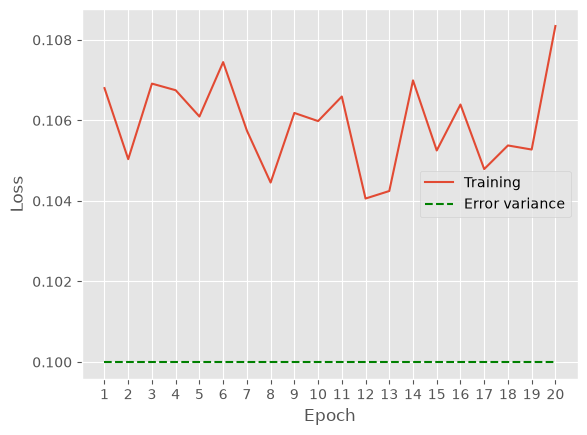

In [13]:
plt.plot(np.arange(1, num_epochs + 1), train["loss"], label="Training")
plt.plot([1,num_epochs], [var,var], "g--", label="Error variance")
plt.xticks(np.arange(1, num_epochs + 1))
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Now compare $g$ with the trained $\widehat{g}$.

type(g_grid) =  <class 'numpy.ndarray'>
type(y_hat) =  <class 'numpy.ndarray'>


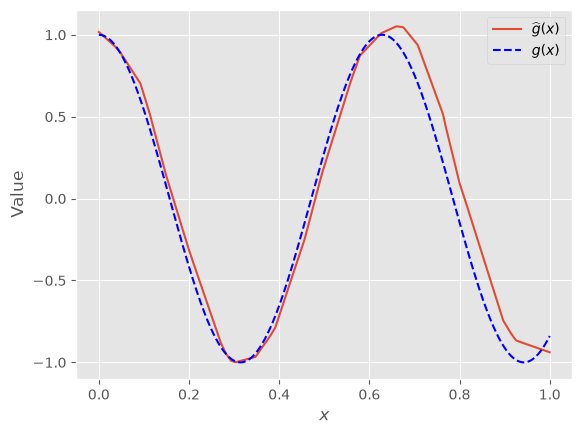

In [14]:
device = next(g_hat.parameters()).device  # get the device the model is currently on

x_grid = np.linspace(0, 1, num=1001)

# Convert to tensor and reshape to (batch_size, 1)
x_grid_t = torch.from_numpy(x_grid).float().reshape(-1, 1).to(device)

# set to evaluation mode
g_hat.eval()   

# disable gradient tracking
with torch.no_grad():   
    # forward pass
    y_hat = g_hat(x_grid_t) 
    # bring back to CPU before converting to numpy
y_hat_np = y_hat.cpu().numpy().flatten()  # bring back to CPU before converting to numpy

g_grid = g(x_grid)

print("type(g_grid) = ", type(g_grid))
print("type(y_hat) = ", type(y_hat_np))

plt.plot(x_grid, y_hat_np, label=r"$\widehat{g}(x)$")
plt.plot(x_grid, g_grid, "b--", label="$g(x)$")
plt.xlabel("$x$")
plt.ylabel("Value")
plt.legend()
plt.show()

The function $g$ is not so hard to learn when we have $N=1\,000\,000$ samples!

To demonstrate the potential problem of <b>overfitting</b> and a regularisation technique called <b>dropout</b>, which mitigates it, we make now the problem harder: we are going to use only the first $200$ samples. In fact, we are going to even split these $200$ samples into a <b>training</b> set of $100$ samples and <b>validation set</b> of $100$ samples.

In [15]:
N_small = 200
x_sub = x[0:N_small]
y_sub = y[0:N_small]

We now specify a blatantly overparameterised network
\begin{equation*}
\widehat{g}_{\mathrm{over}} \in \mathcal{N}_4(1,1000,1000,1000,1;\mathrm{ReLU},\mathrm{ReLU},\mathrm{ReLU},\mathrm{Id}).
\end{equation*}

In [16]:
n = 1000

g_hat_over = nn.Sequential(
    nn.Linear(1, n),
    nn.ReLU(),
    nn.Linear(n, n),
    nn.ReLU(),
    nn.Linear(n, n),
    nn.ReLU(),
    nn.Linear(n, 1)
)

In [17]:
eta = 0.01
optimizer = torch.optim.Adam(g_hat_over.parameters(), lr=eta)
loss_fn = nn.MSELoss()

We train it with Adam using full batches over $500$ epochs.

In [18]:
num_epochs = 500

train = train_model(
    g_hat_over,
    x_sub,
    y_sub,
    loss_fn,
    optimizer,
    epochs=num_epochs,
    batch_size=100,
    validation_split = 0.5,
    verbose_every = 1)

n_total =  200 n_val =  100 n_train =  100
Epoch 1/500, loss: 0.6315, val_loss: 710.6698
Epoch 2/500, loss: 752.9565, val_loss: 312.0930
Epoch 3/500, loss: 323.5476, val_loss: 12.4959
Epoch 4/500, loss: 12.5450, val_loss: 68.0516
Epoch 5/500, loss: 68.9534, val_loss: 4.8206
Epoch 6/500, loss: 5.0421, val_loss: 47.2320
Epoch 7/500, loss: 48.5506, val_loss: 6.2165
Epoch 8/500, loss: 6.4967, val_loss: 17.1298
Epoch 9/500, loss: 17.2374, val_loss: 22.9106
Epoch 10/500, loss: 23.0693, val_loss: 1.3139
Epoch 11/500, loss: 1.3045, val_loss: 9.9613
Epoch 12/500, loss: 10.3396, val_loss: 13.9685
Epoch 13/500, loss: 14.4595, val_loss: 3.0507
Epoch 14/500, loss: 3.2214, val_loss: 2.3105
Epoch 15/500, loss: 2.2954, val_loss: 8.5769
Epoch 16/500, loss: 8.5839, val_loss: 5.5662
Epoch 17/500, loss: 5.5553, val_loss: 0.7943
Epoch 18/500, loss: 0.8026, val_loss: 2.0518
Epoch 19/500, loss: 2.1853, val_loss: 4.6371
Epoch 20/500, loss: 4.8679, val_loss: 3.5684
Epoch 21/500, loss: 3.7630, val_loss: 1.0313


In [20]:
# print(train)

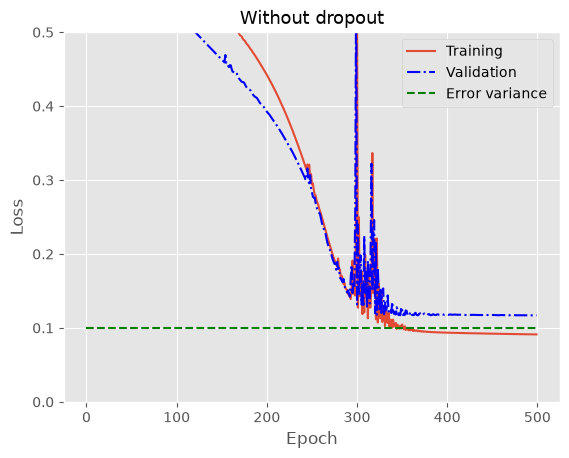

In [22]:
plt.plot(train["loss"], label="Training")
plt.plot(train["val_loss"], "b-.", label="Validation")
plt.plot([0,num_epochs], [var,var], "g--", label="Error variance")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Without dropout", loc='center', fontsize=13)
plt.ylim(0,0.5)
plt.legend()
plt.show()

We note that <b>training loss</b> becomes lower than <b>validation loss</b>, in fact lower than the model error variance 0.1. This is a clear sign of overfitting. Visual assessment confirms that this is indeed true.

In [23]:
this_model = g_hat_over

x_grid = np.linspace(0, 1, num=1001)

# get the device the model is currently on
device = next(this_model.parameters()).device  

# Convert to tensor and reshape to (batch_size, 1)
x_grid_t = torch.from_numpy(x_grid).float().reshape(-1, 1).to(device)

# set to evaluation mode
this_model.eval() 

# disable gradient tracking
with torch.no_grad(): 
    # forward pass
    y_hat = this_model(x_grid_t)   

# bring back to CPU before converting to numpy
y_hat_np = y_hat.cpu().numpy().flatten()  

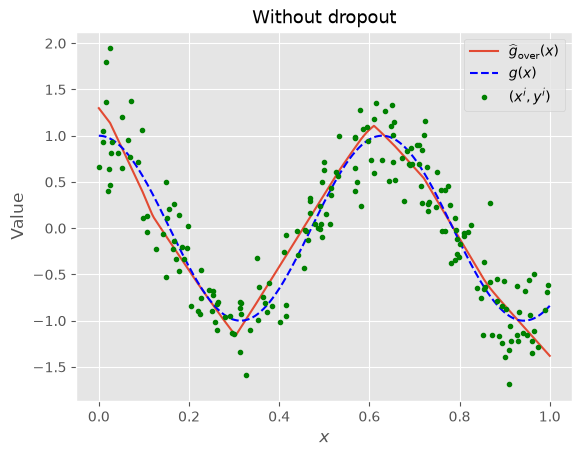

In [24]:
plt.plot(x_grid, y_hat_np, label=r"$\widehat{g}_{\mathrm{over}}(x)$")
plt.plot(x_grid, g_grid, "b--", label="$g(x)$")
plt.plot(x_sub, y_sub, "go", markersize=3, label="$(x^i,y^i)$")
plt.xlabel("$x$")
plt.ylabel("Value")
plt.title("Without dropout", loc='center', fontsize=13)
plt.legend()
plt.show()

Now we apply <b>dropout</b>. In a dropout layer, inputs are randomly replaced by zeros with fixed probability $p \in (0,1)$ at each step of the training. Non-zero inputs are scaled by $\frac{1}{1-p}$ to retain the original magnitude of the sum of inputs. We introduce a dropout layer with dropout probability $p=0.4$ after each hidden layer:

In [25]:
dropout_rate = 0.4
n = 1000

g_hat_dropout = nn.Sequential(
    nn.Linear(1, n),
    nn.ReLU(),
	nn.Dropout(dropout_rate),
    nn.Linear(n, n),
    nn.ReLU(),
	nn.Dropout(dropout_rate),
    nn.Linear(n, n),
    nn.ReLU(),
	nn.Dropout(dropout_rate),
    nn.Linear(n, 1)
)

We compile and train the new network $\widehat{g}_{\mathrm{dropout}}$ with other settings unchanged.

In [26]:
eta = 0.01
optimizer = torch.optim.Adam(g_hat_dropout.parameters(), lr=eta)
loss_fn = nn.MSELoss()

In [27]:
num_epochs = 5000

train = train_model(
    g_hat_dropout,
    x_sub,
    y_sub,
    loss_fn,
    optimizer,
    epochs=num_epochs,
    batch_size=100,
    validation_split = 0.5)

n_total =  200 n_val =  100 n_train =  100
Epoch 10/5000, loss: 0.6336, val_loss: 0.5961
Epoch 20/5000, loss: 0.6111, val_loss: 0.4392
Epoch 30/5000, loss: 0.5129, val_loss: 0.4645
Epoch 40/5000, loss: 0.5026, val_loss: 0.3895
Epoch 50/5000, loss: 0.4459, val_loss: 0.3393
Epoch 60/5000, loss: 0.4107, val_loss: 0.3930
Epoch 70/5000, loss: 0.5058, val_loss: 0.3265
Epoch 80/5000, loss: 0.4301, val_loss: 0.3284
Epoch 90/5000, loss: 0.4482, val_loss: 0.3099
Epoch 100/5000, loss: 0.3935, val_loss: 0.2751
Epoch 110/5000, loss: 0.3757, val_loss: 0.3159
Epoch 120/5000, loss: 0.3392, val_loss: 0.2515
Epoch 130/5000, loss: 0.3488, val_loss: 0.2841
Epoch 140/5000, loss: 0.3187, val_loss: 0.2525
Epoch 150/5000, loss: 0.3649, val_loss: 0.3404
Epoch 160/5000, loss: 0.3648, val_loss: 0.2655
Epoch 170/5000, loss: 0.2790, val_loss: 0.2209
Epoch 180/5000, loss: 0.2977, val_loss: 0.2284
Epoch 190/5000, loss: 0.3818, val_loss: 0.2658
Epoch 200/5000, loss: 0.3212, val_loss: 0.2273
Epoch 210/5000, loss: 0.30

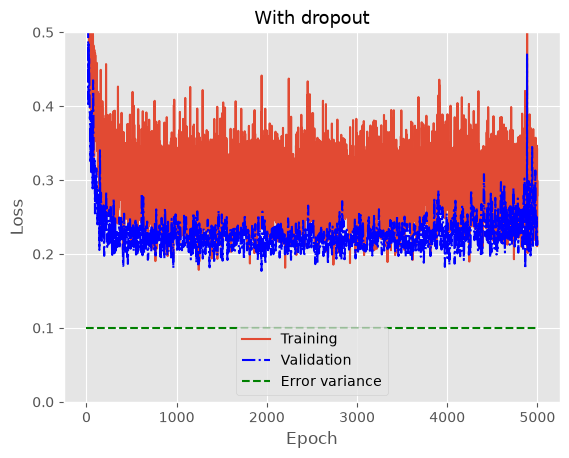

In [28]:
plt.plot(train["loss"], label="Training")
plt.plot(train["val_loss"], "b-.", label="Validation")
plt.plot([0,num_epochs], [var,var], "g--", label="Error variance")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("With dropout", loc='center', fontsize=13)
plt.ylim(0,0.5)
plt.legend()
plt.show()

We do not see a major discrepancy between training and validation losses. Also training loss tends to stay above the model error variance $0.1$. Let us visually study the fit.

In [29]:
this_model = g_hat_dropout

x_grid = np.linspace(0, 1, num=1001)

# get the device the model is currently on
device = next(this_model.parameters()).device  

# Convert to tensor and reshape to (batch_size, 1)
x_grid_t = torch.from_numpy(x_grid).float().reshape(-1, 1).to(device)

# set to evaluation mode
this_model.eval() 

# disable gradient tracking
with torch.no_grad(): 
    # forward pass
    y_hat = this_model(x_grid_t)   

# bring back to CPU before converting to numpy
y_hat_np = y_hat.cpu().numpy().flatten() 

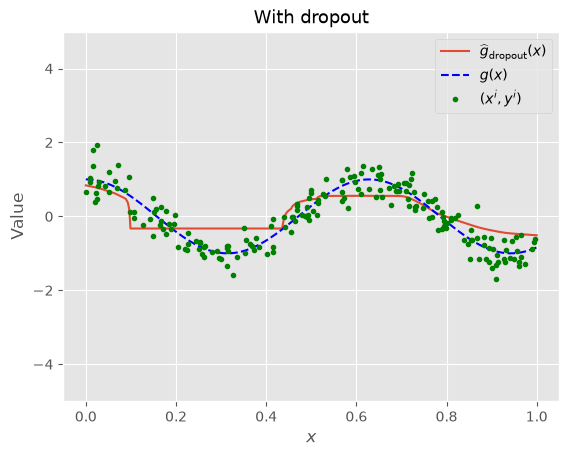

In [30]:
plt.plot(x_grid, y_hat_np, label=r"$\widehat{g}_{\mathrm{dropout}}(x)$")
plt.plot(x_grid, g_grid, "b--", label="$g(x)$")
plt.plot(x_sub, y_sub, "go", markersize=3, label="$(x^i,y^i)$")
plt.xlabel("$x$")
plt.ylabel("Value")
plt.ylim(-5,5)
plt.title("With dropout", loc='center', fontsize=13)
plt.legend()
plt.show()

While the fit is not perfect (due to the small amount of samples), the overfit problem has been mitigated.